In [1]:
import torch
import torch.nn as nn
from torchvision import transforms
import TrashNetDataset as trashnet

import matplotlib.pyplot as plt

/opt/anaconda3/envs/supabase/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/anaconda3/envs/supabase/lib/python3.14/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/Users/demko/Desktop/GDG Hackathon/TrashNetDataset.py:39: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=8, max_width=8, p=0.3),


Total images found: 2527
Training images: 1768
Validation images: 759

Class Mapping: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}
Dataset initialized with 1768 samples.
Dataset initialized with 759 samples.
1768 759


In [2]:
N_CLASSES = 6
class EfficientNetB0Transfer(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.backbone = timm.create_model(
            'efficientnet_b0',
            pretrained=True,
            num_classes=num_classes
        )

        # Freeze entire model
        for p in self.backbone.parameters():
            p.requires_grad = False

        # Replace classifier (timm uses .classifier)
        in_features = self.backbone.classifier.in_features
        self.backbone.classifier = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

In [3]:
MODEL_PATH = r"models/EfficientNet_epoch4.bin"

torch_data = torch.load(MODEL_PATH, weights_only=False)

model = torch_data['model']

In [4]:
trash = trashnet.val_dataset[60]

img = trash['img'].unsqueeze(0)
y = trash['target']

pred = model(img)
print(y)
torch.softmax(pred, axis=-1)

4


tensor([[2.1790e-06, 1.6957e-02, 9.1694e-03, 3.8262e-04, 9.7228e-01, 1.2046e-03]],
       grad_fn=<SoftmaxBackward0>)

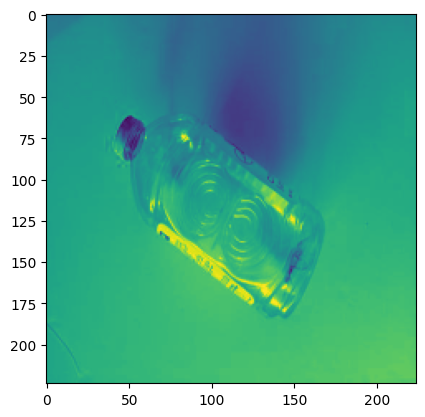

In [5]:
plt.imshow(img[0, 0])

In [18]:
from PIL import Image
import os
import cv2

transform = transforms.Compose([
    transforms.PILToTensor()
])

imgs = []
outputs = []

for files in os.scandir("test_imgs"):
    img = cv2.imread(files.path)
    
    img_tensor = torch.tensor( trashnet.VAL_TRANSFORMS(image=img)['image'], dtype=torch.float ).unsqueeze(0)
    out = model(img_tensor)
    out = torch.softmax(out, axis=-1)
    pred_class_idx = torch.argmax(out, axis=-1).item()
    pred_class = trashnet.IDX2CLASS[pred_class_idx]

    imgs.append(img)
    outputs.append(out)
    
    print(f"Image predicted out: {pred_class}")


/var/folders/t_/yd0v9y410s71vb3k07dv1qm00000gn/T/ipykernel_74315/3032273505.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img_tensor = torch.tensor( trashnet.VAL_TRANSFORMS(image=img)['image'], dtype=torch.float ).unsqueeze(0)


Image predicted out: plastic
Image predicted out: cardboard
